In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import st_clustering as stc
import seaborn as sns
import os

In [3]:
np.random.seed(0)

In [4]:
df = pd.read_csv('cartesian_coordinates_after_ipca.csv')
df_with_time = df
df_without_time = df.iloc[:, 2:].copy()
print(df.head())
print(df_without_time.head())

   time  traj     ipca1     ipca2
0   0.0     1 -1.727034 -0.088990
1   0.0     2 -1.584642  1.263630
2   0.0     3 -4.244976  1.845963
3   0.0     4 -3.672226  1.881696
4   0.0     5 -3.358796  1.362966
      ipca1     ipca2
0 -1.727034 -0.088990
1 -1.584642  1.263630
2 -4.244976  1.845963
3 -3.672226  1.881696
4 -3.358796  1.362966


In [5]:
# Normalisation of ST data
df['ipca1'] = (df['ipca1'] - df['ipca1'].min()) / (df['ipca1'].max() - df['ipca1'].min())
df['ipca2'] = (df['ipca2'] - df['ipca2'].min()) / (df['ipca2'].max() - df['ipca2'].min())
# Transformation to numpy array
data = df.loc[:, ['time','ipca1', 'ipca2']].values

In [6]:
# This is where ST Clustering happens. 
st_spectral = stc.ST_SpectralClustering(eps1=0.1,eps2=20,n_clusters=3)
# st_fit() may be unnecessary here as it only helps the clustering when the data is very large. 
st_spectral.st_fit(data) 

D:\Conda\envs\stcluster\lib\site-packages\st_clustering\st_clustering.py:31: UserWarning: As input data is very large, clustering probably will take some time. Thus, if clustering takes too long, it might make sense to use st_fit_frame_split method.
  warnings.warn('As input data is very large, clustering probably will take some time. Thus, if clustering takes too long, it might make sense to use st_fit_frame_split method.')
D:\Conda\envs\stcluster\lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Conda\envs\stcluster\lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
  File "D:\Conda\envs\stcluster\lib\subprocess.py", l

ST_SpectralClustering(eps1=0.1, eps2=20, n_clusters=3)

In [7]:
df['st_labels'] = st_spectral.labels
df.head()

,time,traj,ipca1,ipca2,st_labels
0,0.0,1,0.476029,0.454244,0
1,0.0,2,0.482060,0.540723,0
2,0.0,3,0.369387,0.577954,0
3,0.0,4,0.393645,0.580239,0
4,0.0,5,0.406919,0.547074,0


In [8]:
# Incorporation of hopping events in our clustering results

df_hops = pd.read_csv("Hopping_Information.csv")
## We cut off the time here at 57.8 as one trajectory only has up to 57.8 fs.
df_hops = df_hops[df_hops["time"] <= 57.8].reset_index(drop=True)

df_plot = df[df["time"] <= 57.8].reset_index(drop=True)
data_plot = df_plot.loc[:, ["ipca1", "ipca2"]].values
labels_st = df_plot["st_labels"].values

hop_mask = (df_hops["Hops2.1"] == 1) | (df_hops["Hops1.2"] == 1)
assert len(df_plot) == len(df_hops)
df_plot["is_hop"] = hop_mask.values

In [9]:
# Normalisation of NonST data
df_without_time['ipca1'] = (df_without_time['ipca1'] - df_without_time['ipca1'].min()) / (df_without_time['ipca1'].max() - df_without_time['ipca1'].min())
df_without_time['ipca2'] = (df_without_time['ipca2'] - df_without_time['ipca2'].min()) / (df_without_time['ipca2'].max() - df_without_time['ipca2'].min())
# Transformation to numpy array 
data = df_without_time[['ipca1', 'ipca2']].values

In [10]:
# This is where NonST clustering happens. 

from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=3,
    assign_labels="discretize",
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=0
)

labels = spectral.fit_predict(data)
df["nonst_labels"] = labels

In [11]:
# Incorporation of hopping events in our clustering results

df_hops = pd.read_csv("Hopping_Information.csv")
# Apply time cutoff
df_hops = df_hops[df_hops["time"] <= 57.8].reset_index(drop=True)

df_plot = df[df["time"] <= 57.8].reset_index(drop=True)

data_plot = df_plot.loc[:, ["ipca1", "ipca2"]].values
labels_nonst = df_plot["nonst_labels"].values

hop_mask = (df_hops["Hops2.1"] == 1) | (df_hops["Hops1.2"] == 1)
df_plot["is_hop"] = hop_mask.values

In [12]:
def plot_with_hops(ax, data, labels, hop_mask, title=None):
    colors = ['#a6cee3', '#1f78b4', '#b2df8a',
              '#33a02c', '#fb9a99', '#e31a1c']

    for i in range(len(set(labels))):
        clust = data[labels == i]
        ax.scatter(
            clust[:, 0], clust[:, 1],
            c=colors[i % len(colors)],
            s=1,
            alpha=0.4,
            label=f"cluster {i}"
        )

    hops = data[hop_mask.values]
    ax.scatter(
        hops[:, 0], hops[:, 1],
        s=40,
        marker="*",
        c="black",
        edgecolors="yellow",
        linewidths=0.5,
        label="hops"
    )

    if title:
        ax.set_title(title)

    ax.legend(markerscale=3)

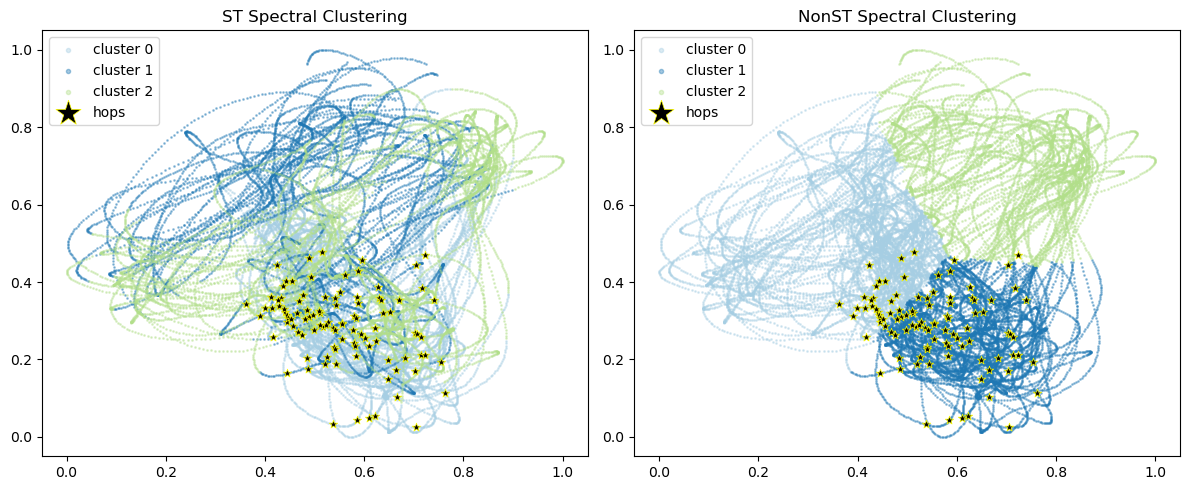

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

plot_with_hops(
    axes[0],
    data_plot,
    labels_st,
    hop_mask,
    title="ST Spectral Clustering"
)

plot_with_hops(
    axes[1],
    data_plot,
    labels_nonst,
    hop_mask,
    title="NonST Spectral Clustering"
)

plt.tight_layout()
plt.savefig("Figure 7", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Counts how many hops are in each ST cluster
st_hop_counts = (
    df_plot[df_plot["is_hop"]]
    .groupby("st_labels")
    .size()
)

print(st_hop_counts)

st_labels
0    63
1     8
2    29
dtype: int64


In [15]:
# Counts how many hops are in each NonST cluster
nonst_hop_counts = (
    df_plot[df_plot["is_hop"]]
    .groupby("nonst_labels")
    .size()
)

print(nonst_hop_counts)

nonst_labels
0    26
1    73
2     1
dtype: int64


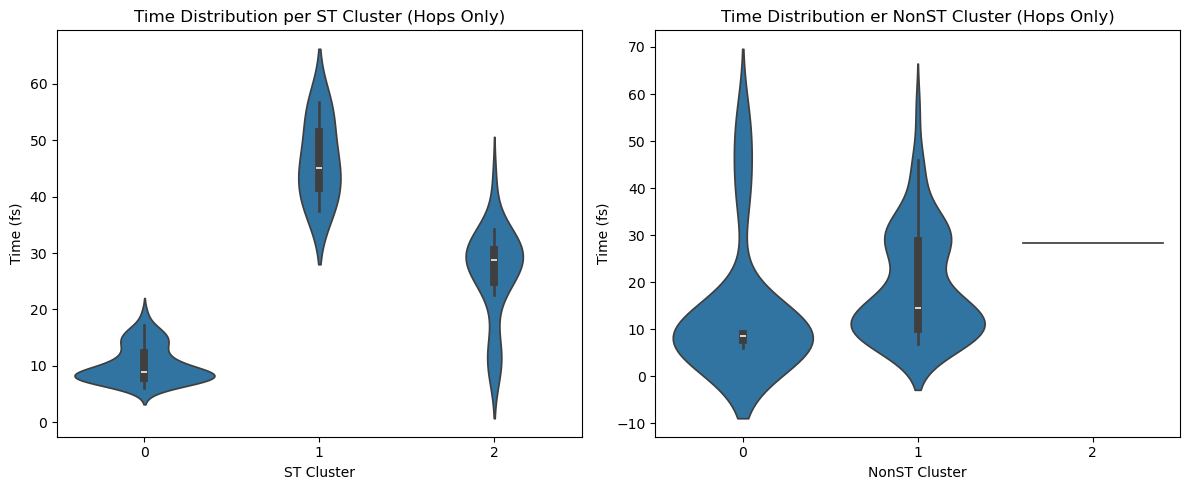

In [16]:
# Performing Violin plot analysis

df_hops_only = df_plot.loc[hop_mask, :]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(
    x="st_labels",
    y="time",
    data=df_hops_only,
    inner="box"
)

plt.xlabel("ST Cluster")
plt.ylabel("Time (fs)")
plt.title("Time Distribution per ST Cluster (Hops Only)")

plt.subplot(1, 2, 2)
sns.violinplot(
    x="nonst_labels",
    y="time",
    data=df_hops_only,
    inner="box"
)

plt.xlabel("NonST Cluster")
plt.ylabel("Time (fs)")
plt.title("Time Distribution er NonST Cluster (Hops Only)")

plt.tight_layout()
plt.savefig("Figure 8", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Read bond length information 
df_r2 = pd.read_csv("Bond_Lengths.csv")
df_r2 = df_r2.sort_values(["time", "traj"]).reset_index(drop=True)
df_r2 = df_r2[["time", "traj"] + [c for c in df_r2.columns if c not in ["time", "traj"]]]
df_r2 = df_r2[df_r2["time"] <= 57.8].reset_index(drop=True)
df_r2.head()

,time,traj,r12,r13,r23,r14,r24,r34,r15,r25,...,r212,r312,r412,r512,r612,r712,r812,r912,r1012,r1112
0,0.0,1,1.447360,2.372673,1.529240,2.392659,2.373981,1.365330,1.395893,2.297261,...,4.522587,4.172448,2.914349,2.236683,1.091192,4.006476,5.540837,5.098959,2.655246,1.683378
1,0.0,2,1.372375,2.344932,1.467465,2.432463,2.333076,1.390720,1.501169,2.262342,...,4.511529,4.151632,2.834202,2.267650,1.266625,4.150521,5.543934,5.006489,2.673773,2.023248
2,0.0,3,1.337090,2.241301,1.479671,2.320758,2.305233,1.302191,1.454909,2.285641,...,4.394986,4.064244,2.871871,2.111464,1.073348,3.737594,5.421591,5.000330,2.808678,1.978175
3,0.0,4,1.344334,2.385565,1.593410,2.370537,2.370456,1.401025,1.410485,2.242483,...,4.350965,3.971502,2.617427,2.140309,1.032350,3.915650,5.289895,4.914751,2.392361,2.046363
4,0.0,5,1.300993,2.291013,1.475554,2.394445,2.335679,1.400136,1.476769,2.268466,...,4.416222,4.225164,2.963914,2.147841,1.046756,3.910404,5.397649,5.080132,2.916854,1.881396


In [18]:
df_hops["st_labels"] = st_spectral.labels
df_hops["nonst_labels"] = labels
df_hops.head()

,time,traj,State,Etot,Hops2.1,Epot1,Hops1.2,DE2.1,st_labels,nonst_labels
0,0.0,1,2,-6271.713990,0,-6276.740507,0,3.852182,0,0
1,0.0,2,2,-6271.297329,0,-6276.439522,0,4.063641,0,0
2,0.0,3,2,-6271.822863,0,-6277.220054,0,4.231454,0,0
3,0.0,4,2,-6270.488770,0,-6276.275546,0,3.969762,0,0
4,0.0,5,2,-6271.352705,0,-6276.827965,0,4.312843,0,0


In [19]:
idx_all_hops = df_hops.query("`Hops2.1` == 1").index.tolist() + df_hops.query("`Hops1.2` == 1").index.tolist()
idx_no_hops = df_hops.query("`Hops2.1` == 0 and `Hops1.2` == 0").index.tolist()

In [20]:
df_hops_st = df_r2.loc[idx_all_hops].copy()
df_hops_st["st_labels"] = df_hops.loc[idx_all_hops, "st_labels"].values

df_hops_nonst = df_r2.loc[idx_all_hops].copy()
df_hops_nonst["nonst_labels"] = df_hops.loc[idx_all_hops, "nonst_labels"].values

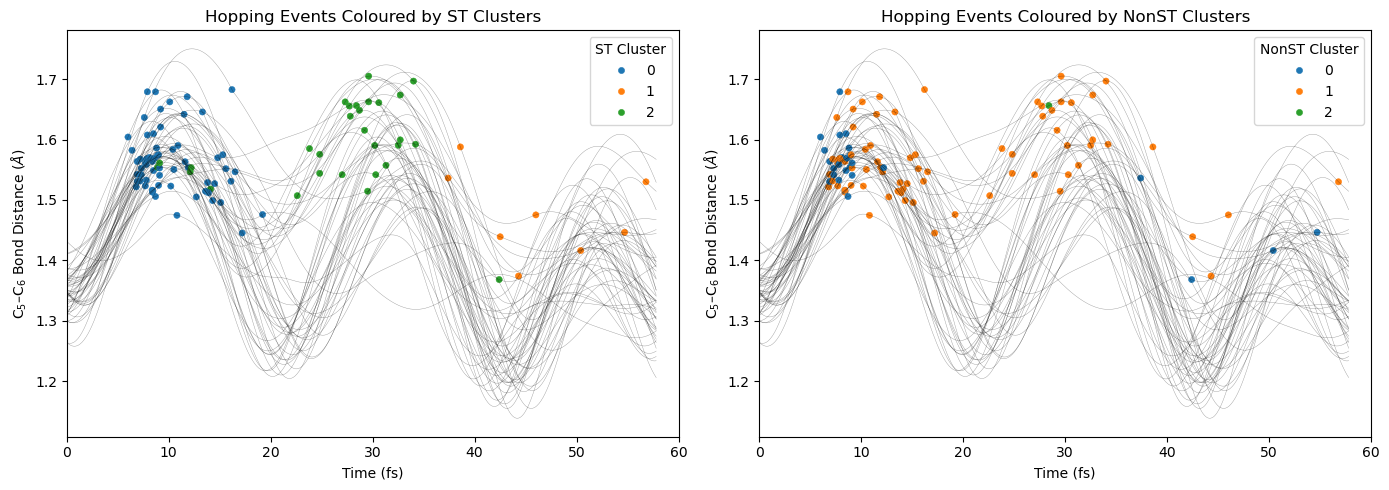

In [21]:
# Plot C5-C6 bond length against time

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===================== ST =====================
ax = axes[0]

# plot all trajectories in background
for traj in df_r2["traj"].unique():
    sub = df_r2[df_r2["traj"] == traj]
    ax.plot(sub["time"], sub["r56"], c="k", lw=0.3, alpha=0.4)

# overlay hopping points coloured by ST cluster
sns.scatterplot(
    data=df_hops_st,
    x="time",
    y="r56",
    hue="st_labels",
    palette="tab10",
    s=20,
    edgecolor=None,
    ax=ax
)

ax.set_title("Hopping Events Coloured by ST Clusters")
ax.set_xlabel("Time (fs)")
ax.set_ylabel(r"C$_5$–C$_6$ Bond Distance ($\AA$)")
ax.set_xlim(0, 60)
ax.legend(title="ST Cluster")


# ===================== NonST =====================
ax = axes[1]

for traj in df_r2["traj"].unique():
    sub = df_r2[df_r2["traj"] == traj]
    ax.plot(sub["time"], sub["r56"], c="k", lw=0.3, alpha=0.4)

sns.scatterplot(
    data=df_hops_nonst,
    x="time",
    y="r56",
    hue="nonst_labels",
    palette="tab10",
    s=20,
    edgecolor=None,
    ax=ax
)

ax.set_title("Hopping Events Coloured by NonST Clusters")
ax.set_xlabel("Time (fs)")
ax.set_ylabel(r"C$_5$–C$_6$ Bond Distance ($\AA$)")
ax.set_xlim(0, 60)
ax.legend(title="NonST Cluster")

plt.tight_layout()
plt.savefig("Figure 9", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# The next few cells on "def" are necessary for calculating the mean dihedral angles.

def check_angle(value):
    abs_value = abs(value)
    if abs_value < 90:
        return abs_value
    else:
        return 180.0 - abs_value

In [23]:
def calculate_bond_length(atom1, atom2):
    """
    Calculate the bond length between two atoms given their Cartesian coordinates.

    Parameters:
    atom1 (tuple/list/ndarray): Cartesian coordinates of the first atom (x1, y1, z1).
    atom2 (tuple/list/ndarray): Cartesian coordinates of the second atom (x2, y2, z2).

    Returns:
    float: The bond length between the two atoms.
    """
    # Convert input to numpy arrays for easy computation
    atom1 = np.array(atom1)
    atom2 = np.array(atom2)

    # Calculate the Euclidean distance (bond length)
    bond_length = np.linalg.norm(atom1 - atom2)

    return bond_length

In [24]:
def calculate_dihedral_angle(atom1, atom2, atom3, atom4):
    """
    Calculate the dihedral angle between four atoms given their Cartesian coordinates.

    Parameters:
    atom1, atom2, atom3, atom4 (tuple/list/ndarray): Cartesian coordinates of the atoms.

    Returns:
    float: The dihedral angle in degrees.
    """
    # Convert input to numpy arrays
    atom1 = np.array(atom1)
    atom2 = np.array(atom2)
    atom3 = np.array(atom3)
    atom4 = np.array(atom4)

    # Calculate vectors between atoms
    b1 = atom2 - atom1
    b2 = atom3 - atom2
    b3 = atom4 - atom3

    # Normalize b2
    b2 /= np.linalg.norm(b2)

    # Calculate normals to planes
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)

    # Calculate the angle between the normals
    x = np.dot(n1, n2)
    y = np.dot(np.cross(n1, b2), n2)

    angle = np.degrees(np.arctan2(y, x))

    return angle

In [25]:
def calc_bonds_and_diheds(df):

    df_bonds_diheds = df[["traj", "time"]].copy()

    df_bonds_diheds["bond_56"] = df.apply(
        lambda row: calculate_bond_length(
            (row["x5"], row["y5"], row["z5"]), (row["x6"], row["y6"], row["z6"])
        ),
        axis=1,
    )

    df_bonds_diheds["cis1"] = df.apply(
        lambda row: calculate_dihedral_angle(
            (row["x1"], row["y1"], row["z1"]),
            (row["x5"], row["y5"], row["z5"]),
            (row["x6"], row["y6"], row["z6"]),
            (row["x11"], row["y11"], row["z11"]),
        ),
        axis=1,
    )

    df_bonds_diheds["cis2"] = df.apply(
        lambda row: calculate_dihedral_angle(
            (row["x4"], row["y4"], row["z4"]),
            (row["x5"], row["y5"], row["z5"]),
            (row["x6"], row["y6"], row["z6"]),
            (row["x12"], row["y12"], row["z12"]),
        ),
        axis=1,
    )

    df_bonds_diheds["trans1"] = df.apply(
        lambda row: calculate_dihedral_angle(
            (row["x1"], row["y1"], row["z1"]),
            (row["x5"], row["y5"], row["z5"]),
            (row["x6"], row["y6"], row["z6"]),
            (row["x12"], row["y12"], row["z12"]),
        ),
        axis=1,
    )

    df_bonds_diheds["trans2"] = df.apply(
        lambda row: calculate_dihedral_angle(
            (row["x4"], row["y4"], row["z4"]),
            (row["x5"], row["y5"], row["z5"]),
            (row["x6"], row["y6"], row["z6"]),
            (row["x11"], row["y11"], row["z11"]),
        ),
        axis=1,
    )

    columns_to_process = ["cis1", "cis2", "trans1", "trans2"]

    for col in columns_to_process:
        # newcolname = f"new_{col}"
        df_bonds_diheds[col] = df_bonds_diheds[col].apply(check_angle)

    df_bonds_diheds["mean_angle"] = (
        df_bonds_diheds["cis1"]
        + df_bonds_diheds["cis2"]
        + df_bonds_diheds["trans1"]
        + df_bonds_diheds["trans2"]
    ) / 4

    return df_bonds_diheds

In [26]:
# Information on the cartesian coordinates are needed for this calculation. 
df_xyz = pd.read_csv("Cartesian Coordinates (raw).csv")
df_xyz = df_xyz[df_xyz["time"] <= 57.8].reset_index(drop=True)
df_xyz

,time,traj,x1,x2,x3,x4,x5,x6,x7,x8,...,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12
0,0.0,1,-10.752992,-11.043320,-8.359874,-6.642325,-8.176536,-7.007656,-12.232375,-12.470717,...,0.121451,-0.173208,0.036594,0.119593,-0.411316,0.059939,-0.370038,0.182604,0.457648,0.319186
1,0.0,2,-10.850547,-10.954595,-8.415192,-6.619959,-8.071728,-7.073622,-12.364031,-12.553674,...,-0.116608,0.104895,-0.092966,0.145189,0.753552,0.133349,0.356253,0.051634,-0.468190,0.146320
2,0.0,3,-10.681181,-10.989212,-8.405375,-6.688721,-8.000477,-7.123694,-11.886039,-12.906878,...,0.064444,-0.071177,0.029237,0.075481,0.128988,0.024216,-0.098846,0.130225,0.060429,0.284318
3,0.0,4,-10.815299,-11.046154,-8.286632,-6.653791,-8.229538,-6.900621,-12.147511,-12.687702,...,0.006959,-0.108703,0.197027,0.038770,-0.040646,-0.478257,0.393453,0.065101,-0.290117,0.006378
4,0.0,5,-10.738006,-10.967441,-8.472467,-6.597798,-8.030128,-7.097055,-12.289186,-12.362934,...,-0.125581,0.030340,0.053278,0.015329,-0.376563,0.207915,0.541036,0.123773,0.644306,0.070763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28945,57.8,46,-10.742218,-10.958927,-8.495327,-6.680736,-8.104696,-6.943191,-12.400600,-12.929007,...,-0.037682,0.011073,0.151214,0.011802,-0.121467,-0.298482,-0.254542,0.224478,0.202074,-0.856435
28946,57.8,47,-10.968537,-11.090374,-8.378329,-6.484264,-7.995527,-7.091359,-12.453349,-13.076136,...,0.056439,-0.016137,0.082842,0.143531,0.865309,-0.004664,0.106615,-0.589240,0.094643,0.090332
28947,57.8,48,-10.720509,-10.838693,-8.252640,-6.751701,-8.127047,-7.255349,-12.952845,-12.845064,...,-0.273687,0.132327,0.063953,-0.026305,0.370052,-0.232026,-0.152109,0.418891,-0.066034,-0.081114
28948,57.8,49,-10.696495,-10.908909,-8.285048,-6.752610,-8.170372,-7.193500,-12.644260,-12.834658,...,-0.189151,-0.109041,-0.036302,0.070045,0.193282,0.295218,0.071071,0.008648,-1.257831,1.674940


In [27]:
# Now the calculation
df_bonds_diheds = calc_bonds_and_diheds(df=df_xyz)

In [28]:
df_bonds_diheds = df_bonds_diheds.sort_values(["time", "traj"]).reset_index(drop=True)
df_bonds_diheds = df_bonds_diheds[["time", "traj"] + [c for c in df_bonds_diheds.columns if c not in ["time", "traj"]]]
df_bonds_diheds["is_hop"] = hop_mask.values
df_bonds_diheds["st_labels"] = df_hops["st_labels"].values
df_bonds_diheds["nonst_labels"] = df_hops["nonst_labels"].values
df_bonds_diheds = df_bonds_diheds[df_bonds_diheds["is_hop"]]
df_bonds_diheds

,time,traj,bond_56,cis1,cis2,trans1,trans2,mean_angle,is_hop,st_labels,nonst_labels
3031,6.0,32,3.031335,1.856815,10.796446,0.870148,8.069483,5.398223,True,0,0
3200,6.4,1,2.989893,8.576241,0.394687,7.006978,15.977906,7.988953,True,0,0
3417,6.8,18,2.875342,23.969463,10.639368,8.213427,26.395403,17.304415,True,0,1
3455,6.9,6,2.955019,10.923577,24.114375,21.921694,13.116258,17.518976,True,0,0
3470,6.9,21,2.914593,1.086191,4.059981,4.776716,0.369456,2.573086,True,0,1
...,...,...,...,...,...,...,...,...,...,...,...
22167,44.3,18,2.596714,55.435536,41.998101,54.274615,43.159023,48.716819,True,1,1
23016,46.0,17,2.787780,82.775145,50.675764,62.555048,70.895861,66.725454,True,1,1
25206,50.4,7,2.676417,75.525483,65.941122,61.623983,79.842622,70.733303,True,1,0
27380,54.7,31,2.733348,81.566175,64.108014,63.566351,82.107838,72.837095,True,1,0


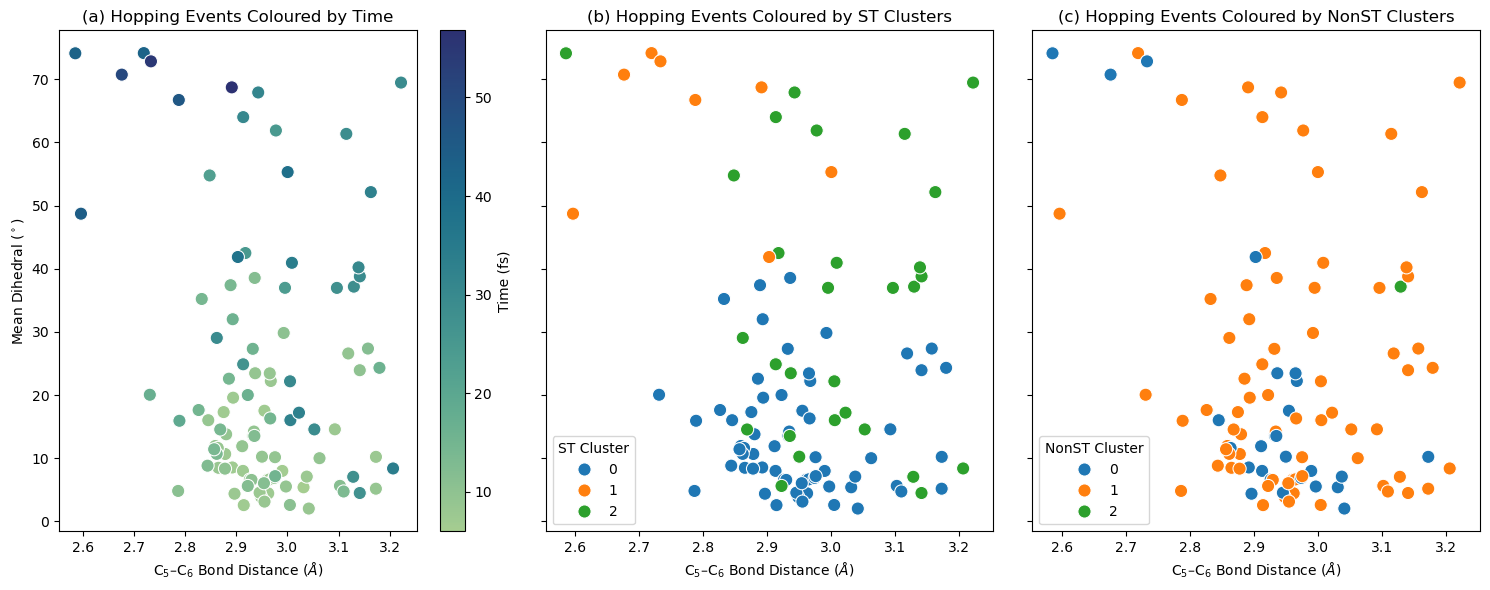

In [29]:
# Plot mean dihedral angles against C5-C6 bond length

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)

# =========================
# (a) TIME (continuous)
# =========================
time_norm = Normalize(
    df_bonds_diheds["time"].min(),
    df_bonds_diheds["time"].max()
)
time_cmap = sns.color_palette("crest", as_cmap=True)
sm_time = ScalarMappable(norm=time_norm, cmap=time_cmap)

sns.scatterplot(
    data=df_bonds_diheds,
    x="bond_56",
    y="mean_angle",
    hue="time",
    palette=time_cmap,
    ax=axs[0],
    legend=False,
    s=90
)

axs[0].set_title("(a) Hopping Events Coloured by Time")
axs[0].set_xlabel(r"C$_5$–C$_6$ Bond Distance ($\AA$)")
axs[0].set_ylabel(r"Mean Dihedral ($^\circ$)")

cbar_time = fig.colorbar(sm_time, ax=axs[0])
cbar_time.set_label("Time (fs)")

# =========================
# (b) ST LABELS (DISCRETE)
# =========================
st_palette = {
    0: "#1f77b4",  # blue
    1: "#ff7f0e",  # orange
    2: "#2ca02c",  # green
}

sns.scatterplot(
    data=df_bonds_diheds,
    x="bond_56",
    y="mean_angle",
    hue="st_labels",
    palette=st_palette,
    ax=axs[1],
    s=90
)

axs[1].set_title("(b) Hopping Events Coloured by ST Clusters")
axs[1].set_xlabel(r"C$_5$–C$_6$ Bond Distance ($\AA$)")
axs[1].set_ylabel("")
axs[1].legend(title="ST Cluster")

# =========================
# (c) NON-ST LABELS (DISCRETE)
# =========================
nonst_palette = {
    0: "#1f77b4",  # blue
    1: "#ff7f0e",  # orange
    2: "#2ca02c",  # green
}

sns.scatterplot(
    data=df_bonds_diheds,
    x="bond_56",
    y="mean_angle",
    hue="nonst_labels",
    palette=nonst_palette,
    ax=axs[2],
    s=90
)

axs[2].set_title("(c) Hopping Events Coloured by NonST Clusters")
axs[2].set_xlabel(r"C$_5$–C$_6$ Bond Distance ($\AA$)")
axs[2].set_ylabel("")
axs[2].legend(title="NonST Cluster")

plt.tight_layout()
plt.savefig("Figure 10", dpi=300, bbox_inches="tight")
plt.show()